GPU available: True
device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.9MB/s]


tiny imagenet not found, using CIFAR-10 resized to 64x64


100%|██████████| 170M/170M [00:05<00:00, 33.8MB/s]


rgb dataset: 50000 train, 10 classes
training MNIST CNN...
[MNIST] ep 1 | loss 0.1970 | acc 94.2%
[MNIST] ep 2 | loss 0.0531 | acc 98.3%
[MNIST] ep 4 | loss 0.0288 | acc 99.1%
[MNIST] ep 6 | loss 0.0173 | acc 99.4%
[MNIST] ep 8 | loss 0.0127 | acc 99.6%
[MNIST] test acc: 99.16%

training TinyImageNet CNN...
[TIN] ep 1 | loss 1.3523 | acc 51.4%
[TIN] ep 2 | loss 0.9347 | acc 67.2%
[TIN] ep 4 | loss 0.5346 | acc 81.5%
[TIN] ep 6 | loss 0.2119 | acc 92.6%
[TIN] ep 8 | loss 0.1046 | acc 96.4%
[TIN] ep 10 | loss 0.0710 | acc 97.7%
[TIN] test acc: 69.88%


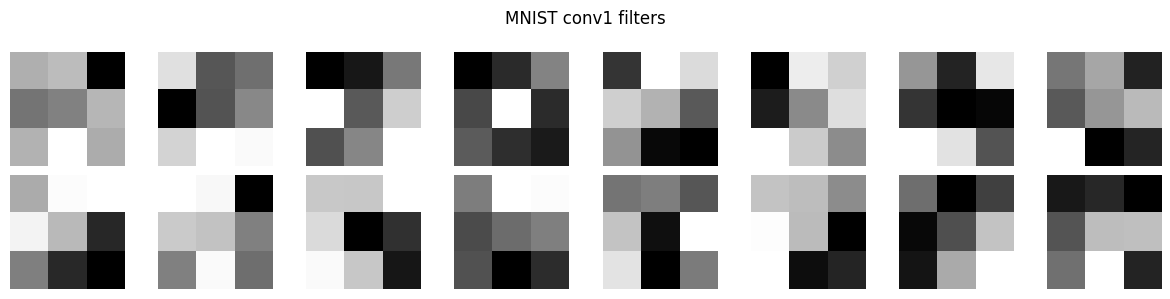

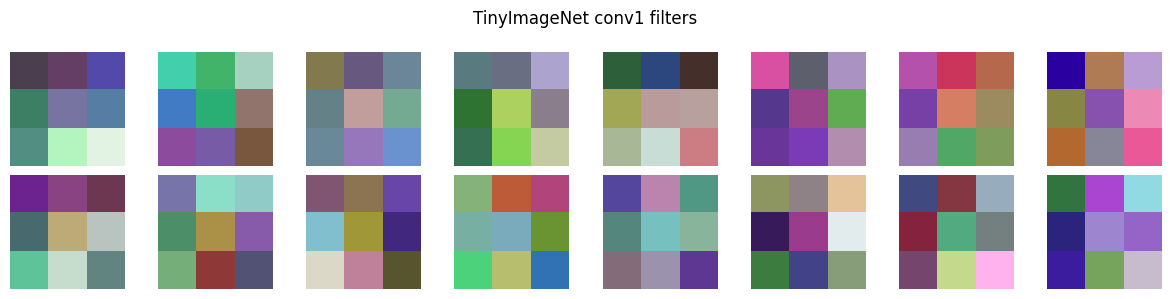

MNIST sample digit: 4


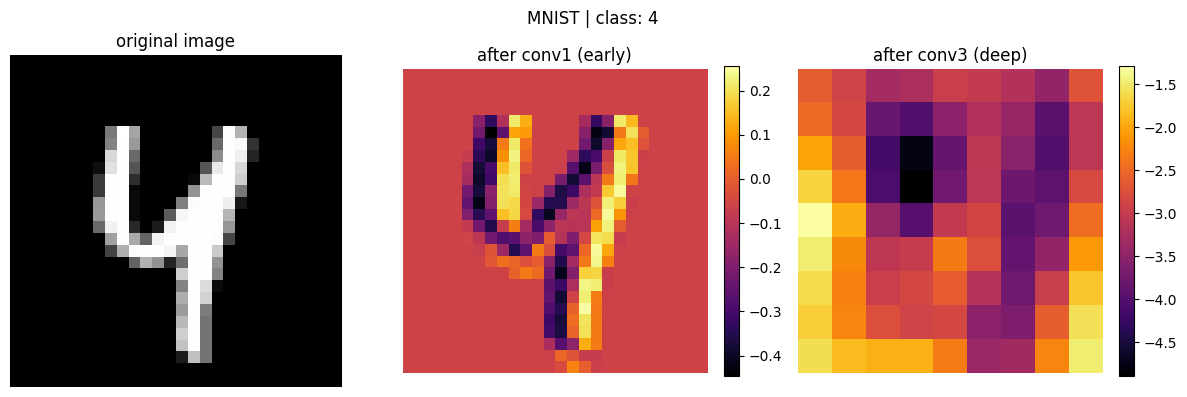

TIN sample: 3 (cat)


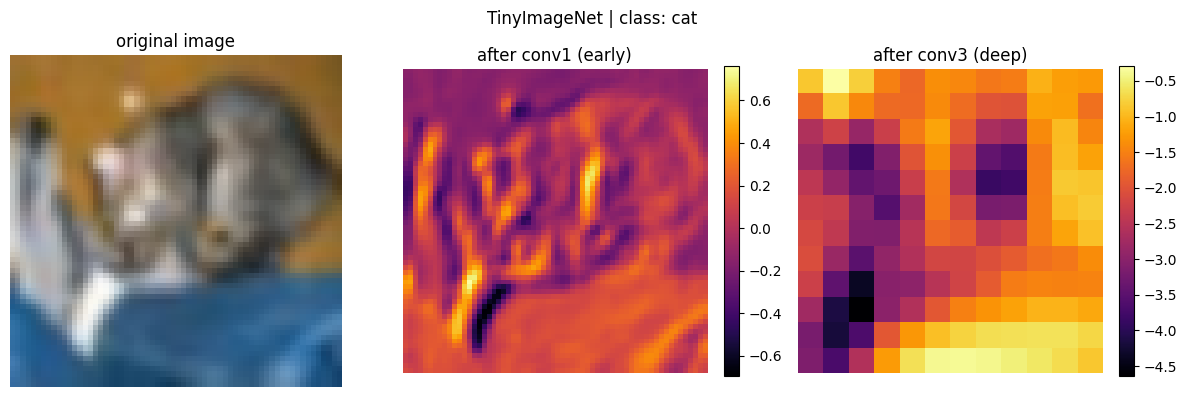

In [1]:
%matplotlib inline
import torch
print("GPU available:", torch.cuda.is_available())

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1   = nn.Linear(64 * 4 * 4, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28->26->13
        x = F.relu(self.conv2(x))             # 13->11
        x = self.pool(F.relu(self.conv3(x)))  # 11->9->4
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class TINNet(nn.Module):
    def __init__(self, n_classes=10):
        super(TINNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1   = nn.Linear(64 * 12 * 12, 256)
        self.fc2   = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64->62->31
        x = self.pool(F.relu(self.conv2(x)))  # 31->29->14
        x = F.relu(self.conv3(x))             # 14->12
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# load MNIST
mnist_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
mnist_train = datasets.MNIST('./data', train=True,  download=True, transform=mnist_tf)
mnist_test  = datasets.MNIST('./data', train=False, download=True, transform=mnist_tf)
mnist_train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=256)

# Tiny ImageNet-10 (falls back to CIFAR-10)
TIN_PATH = './data/tiny-imagenet-10'
tin_tf = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.4802, 0.4481, 0.3975], [0.2302, 0.2265, 0.2262])
])
if os.path.exists(TIN_PATH):
    tin_train = datasets.ImageFolder(os.path.join(TIN_PATH, 'train'), transform=tin_tf)
    tin_test  = datasets.ImageFolder(os.path.join(TIN_PATH, 'val'),   transform=tin_tf)
else:
    print("tiny imagenet not found, using CIFAR-10 resized to 64x64")
    tin_train = datasets.CIFAR10('./data', train=True,  download=True, transform=tin_tf)
    tin_test  = datasets.CIFAR10('./data', train=False, download=True, transform=tin_tf)

tin_train_loader = DataLoader(tin_train, batch_size=64, shuffle=True)
tin_test_loader  = DataLoader(tin_test,  batch_size=128)
n_classes = len(tin_train.classes)
print(f"rgb dataset: {len(tin_train)} train, {n_classes} classes")

def train_and_eval(model, train_loader, test_loader, epochs=8, lr=1e-3, name=''):
    opt     = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for ep in range(1, epochs + 1):
        model.train()
        total_loss, correct, n = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out  = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            n          += x.size(0)
        if ep % 2 == 0 or ep == 1:
            print(f"[{name}] ep {ep} | loss {total_loss/n:.4f} | acc {correct/n*100:.1f}%")
    model.eval()
    c, n = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            c += (model(x).argmax(1) == y).sum().item()
            n += x.size(0)
    print(f"[{name}] test acc: {c/n*100:.2f}%")
    return model


mnist_model = MNISTNet().to(device)
tin_model   = TINNet(n_classes=n_classes).to(device)

print("training MNIST CNN...")
mnist_model = train_and_eval(mnist_model, mnist_train_loader, mnist_test_loader, epochs=8, name='MNIST')

print("\ntraining TinyImageNet CNN...")
tin_model = train_and_eval(tin_model, tin_train_loader, tin_test_loader, epochs=10, name='TIN')

# Q3.1 - visualize first layer filters
def visualize_filters(model, title, is_rgb=False):
    filters = model.conv1.weight.data.clone().cpu()
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min + 1e-8)

    n = filters.shape[0]
    cols = 8
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 1.5, rows * 1.5))
    plt.suptitle(title, fontsize=12)
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        if is_rgb:
            plt.imshow(filters[i].permute(1, 2, 0).numpy())
        else:
            plt.imshow(filters[i][0].numpy(), cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


visualize_filters(mnist_model, 'MNIST conv1 filters',        is_rgb=False)
visualize_filters(tin_model,   'TinyImageNet conv1 filters', is_rgb=True)

# Q3.2 - activation maps after conv1 and conv3
def get_activations(model, img_tensor, layer_names):
    acts  = {}
    hooks = []

    def make_hook(name):
        def hook(mod, inp, out):
            acts[name] = out.detach().cpu()
        return hook

    for name, module in model.named_modules():
        if name in layer_names:
            hooks.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        model(img_tensor.unsqueeze(0).to(device))

    for h in hooks:
        h.remove()
    return acts


def plot_activation_maps(model, img, layers, title, is_rgb=False, label=''):
    acts = get_activations(model, img, layers)

    fig, axes = plt.subplots(1, 1 + len(layers), figsize=((1 + len(layers)) * 4, 4))
    fig.suptitle(f'{title} | class: {label}')

    if is_rgb:
        mean = torch.tensor([0.4802, 0.4481, 0.3975]).view(3, 1, 1)
        std  = torch.tensor([0.2302, 0.2265, 0.2262]).view(3, 1, 1)
        disp = (img.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[0].imshow(disp)
    else:
        axes[0].imshow(img.cpu().squeeze(), cmap='gray')
    axes[0].set_title('original image')
    axes[0].axis('off')

    subtitles = ['after conv1 (early)', 'after conv3 (deep)']
    for i, lname in enumerate(layers):
        mean_act = acts[lname][0].mean(0).numpy()
        im = axes[i + 1].imshow(mean_act, cmap='inferno')
        axes[i + 1].set_title(subtitles[i])
        axes[i + 1].axis('off')
        plt.colorbar(im, ax=axes[i + 1], fraction=0.046)

    plt.tight_layout()
    plt.show()


# MNIST
sample_img, sample_label = mnist_test[42]
print(f"MNIST sample digit: {sample_label}")
plot_activation_maps(mnist_model, sample_img, ['conv1', 'conv3'],
                     'MNIST', is_rgb=False, label=str(sample_label))

# TinyImageNet
tin_img, tin_label = tin_test[0]
print(f"TIN sample: {tin_label} ({tin_train.classes[tin_label]})")
plot_activation_maps(tin_model, tin_img, ['conv1', 'conv3'],'TinyImageNet', is_rgb=True, label=tin_train.classes[tin_label])

